# COMBINE ANNOTATIONS

In [1]:
import json
import os
from pymongo import MongoClient
from datetime import datetime, timezone
from collections import defaultdict

total_videos = 900


def calculate_iou(box1, box2):
    """Calculate Intersection over Union for two boxes [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0



def make_group(group_id, bbox, confidence) -> dict:
    return {
        "groupId": group_id,
        "bbox": bbox,
        "confidence": confidence
    }
    

def make_annotation(video_index, watched, totalwatchtimes, groups, annotation_frame) -> dict:
    """Create a single video annotation entry."""
    
    timestamp = datetime.now(timezone.utc).isoformat()
    
    return {
        "timestamp": timestamp,
        "videoIndex": video_index,
        "videoFolder": f"videos/clip_{video_index:04d}/",
        "videoWatched": watched,
        "totalWatchTimeMs": totalwatchtimes,
        "numberOfGroups": len(groups),
        "groups": groups,
        "videoInfo": {
            "totalFrames": 50,
            "annotationFrame": annotation_frame,
            "coordinateSystem": "normalized",
            "normalizedWidth": 1920,
            "normalizedHeight": 1080
        }
    }

os.makedirs("../results", exist_ok=True)
    
MONGO_URI = os.getenv('MONGO_URI', 'mongodb://localhost:27017/')
MONGO_DB = 'video_annotations'
    
client = MongoClient(MONGO_URI)
db = client[MONGO_DB]

annotations_collection = db['annotations']
yes_no_annotations_collection = db['yes_no_annotations']

videoFolder = annotations_collection.aggregate([
    { "$group": { "_id": "$videoFolder" } },
    { "$sort": { "_id": 1 } }
])

video_folders = sorted(set([vid['_id'] for vid in list(videoFolder)]))

root = {"completedAt": datetime.now(timezone.utc).isoformat(),"totalVideos": total_videos,"annotations": []}

for folder in video_folders:

    for frame in [1,21,41]:
    
        ind = int(folder.split("_")[1])
    
        test = annotations_collection.aggregate([
            {
                "$match": {
                    "videoFolder": folder,
                    "videoInfo.annotationFrame": frame
                }
            },
            {
                "$unwind": {
                    "path": "$groups",
                    "preserveNullAndEmptyArrays": False}
            },
            {
                "$project": {
                    "_id": 0,
                    "videoFolder": 1,
                    "annotator_id": 1,
                    "annotationFrame": "$videoInfo.annotationFrame",
                    "bbox": "$groups.bbox",
                    "confidence": "$groups.confidence"
                }
            }
        ])    
        
        data = list(test)
    
        #print(data)

        if data == []:
            root["annotations"].append(make_annotation(ind, 0, 0, [], frame))
            continue
        
        frames = defaultdict(lambda: defaultdict(list))
                
        for item in data:
            frame = item["annotationFrame"]
            annotator = item["annotator_id"]
            frames[frame][annotator].append(item["bbox"])
                
        results = [
            list(annotator_groups.values())
            for frame, annotator_groups in sorted(frames.items())
        ]
    

        #print(results)
        
        confidences = defaultdict(lambda: defaultdict(list))
                
        for item in data:
            frame = item["annotationFrame"]
            annotator = item["annotator_id"]
            confidences[frame][annotator].append(item["confidence"])
                
        conf_results = [
            list(annotator_groups.values())
            for frame, annotator_groups in sorted(confidences.items())
        ]
    
        #print(conf_results)
    
        choices_frame = list(set([dat['annotationFrame'] for dat in data]))
        choices_frame.sort()
    
    
        groups = []
        idx = 0
        for idx_group, annotator_group in enumerate(results[0]):

            
            for idx_box, annotator_box in enumerate(annotator_group):
                #print(annotator_box)
                matched = False
    
                for current_group in groups:
                    #print(current_group)
                    if calculate_iou(annotator_box, current_group['bbox']) > 0.5:
                        matched = True
                        break
            
                if not matched:
                    group = make_group(idx, annotator_box, conf_results[0][idx_group][idx_box])
                    groups.append(group)
                    idx+=1
                    
                    #print(groups)
    
        root["annotations"].append(make_annotation(ind, 0, 0, groups, frame))

filename = "../results/all_annotations.json"
with open(filename, "w", encoding="utf-8") as f:
    json.dump(root, f, indent=4)


# READ SBU ANNOTATIONS to generate GT


In [4]:
# READ SBU ANNOTATIONS to generate GT
import json

with open('../results/all_annotations.json', 'r') as f:
    data = json.load(f)

counter = 15
for annotations in data['annotations']:

    ann_frame = annotations['videoInfo']['annotationFrame']
    idx = annotations['videoIndex']

    #print(idx)
    #print(ann_frame)
    for group in annotations['groups']:
        
        x1, y1, x2, y2 = group['bbox']
        group_label = group['groupId']
        dc  = 1
        lvl = 1
        
        GT_list = [idx, ann_frame, x1, y1, x2, y2, group_label, dc, lvl]
        str_to_be_added = [str(k) for k in GT_list]
        str_to_be_added = (" ".join(str_to_be_added))
        f = open('../results/gt_sekai_ours_'+str(ann_frame)+'.txt', "a+")
        f.write(str_to_be_added + "\r\n")
        f.close()


# PLOT ANNOTATED DATA

In [3]:
# READ SBU ANNOTATIONS to generate GT
import json
import cv2
from matplotlib.patches import Rectangle
import numpy as np
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

#with open('annotations/sbu_annotations.json', 'r') as f:
#    data = json.load(f)

save_data = False

os.makedirs("../results/fig_annotations", exist_ok=True)

#os.mkdir()

with open('../results/all_annotations.json', 'r') as f:
    data = json.load(f)


frequencies = np.zeros(100)
avg_score   = []
crowd_confidence  = [[],[],[]]
area_confidence   = [[],[],[]]
region_confidence = defaultdict(list)
region_density = defaultdict(lambda: [0,0,0])



confidence_colors = [
            (255/255, 0/255, 0/255),       # Red
            (255/255, 165/255, 0/255),     # Orange
            (255/255, 255/255, 0/255),     # Yellow
            (0/255, 255/255, 128/255),     # Lime Green
            (0/255, 128/255, 255/255)      # Teal/Cyan
        ]

max_tam = 0

with open('clip_to_region.pkl', 'rb') as f: # CREATE IT IN GENERAL_STATISTICS.IPYNB
    clip_to_region = pickle.load(f)



for idx, annotations in enumerate(tqdm(data['annotations'])):

    
    directory_path = annotations['videoFolder']
    #print(directory_path)
    frame = annotations['videoInfo']['annotationFrame']
    img_path = '../'+directory_path+str(frame+1).zfill(5)+'.jpeg'
    #print(img_path)
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #w,h = image.shape[:2]
    h, w = image.shape[:2]
    if save_data:
        fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=300)
        ax.imshow(image)

        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)

    tam = len(annotations['groups'])
    #print(tam)
    max_tam = max(max_tam, tam)
    frequencies[tam]+=1


    for group in annotations['groups']:

        x1, y1, x2, y2 = group['bbox']
        group_label = group['groupId']

        color = confidence_colors[group['confidence']-1]

        if save_data:
            rect = plt.Rectangle((x1,y1), x2-x1,y2-y1, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
    
        avg_score.append(group['confidence'])
        crowd_confidence[(idx//3)%3].append(group['confidence'])
        area = (x2 - x1) * (y2 - y1)
        if area <= 100*100:
            area_confidence[0].append(group['confidence'])
        elif area <= 500*500:
            area_confidence[1].append(group['confidence'])
        else:
            area_confidence[2].append(group['confidence'])
    
        region_confidence[clip_to_region[directory_path.split('/')[-2]]].append(group['confidence'])
    
    region_density[clip_to_region[directory_path.split('/')[-2]]][(idx//3)%3]+=1
    
    if save_data:
        confidence_values = [1,2,3,4,5]
        legend_patches = [Rectangle((0,0),1,1, facecolor='none', edgecolor=confidence_colors[i], linewidth=3)
                      for i in range(len(confidence_values))]
        legend_labels = [f"{conf:.2f}" for conf in confidence_values]
        
        ax.legend(legend_patches, legend_labels, title="Confidence", loc='upper right', frameon=False)
    
        # Legend with smaller, bold, white text
        legend = ax.legend(
            legend_patches,
            legend_labels,
            title="Confidence",
            loc='upper right',
            frameon=False,
            prop={'size':5.5, 'weight':'bold'},  # smaller, bold text
            title_fontsize=5
        )
        # Set legend text and title color to white
        for text in legend.get_texts():
            text.set_color("white")
        legend.get_title().set_color("white")
        legend.get_title().set_fontweight('bold')  # make title bold
        
        
        ax.axis('off')
        plt.savefig("../results/fig_annotations/coarse_"+str(idx)+".pdf",dpi=300,bbox_inches='tight', pad_inches=0)
        #plt.show()
        plt.close()


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2700/2700 [00:39<00:00, 68.27it/s]


## FREQUENCY AND CONFIDENCES

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
[436. 478. 395. 323. 283. 226. 157. 119. 105.  60.  34.  29.  10.  14.
   6.   4.   6.   4.   3.   0.   3.   1.   2.   0.   0.   2.   0.   0.
   0.   0.]


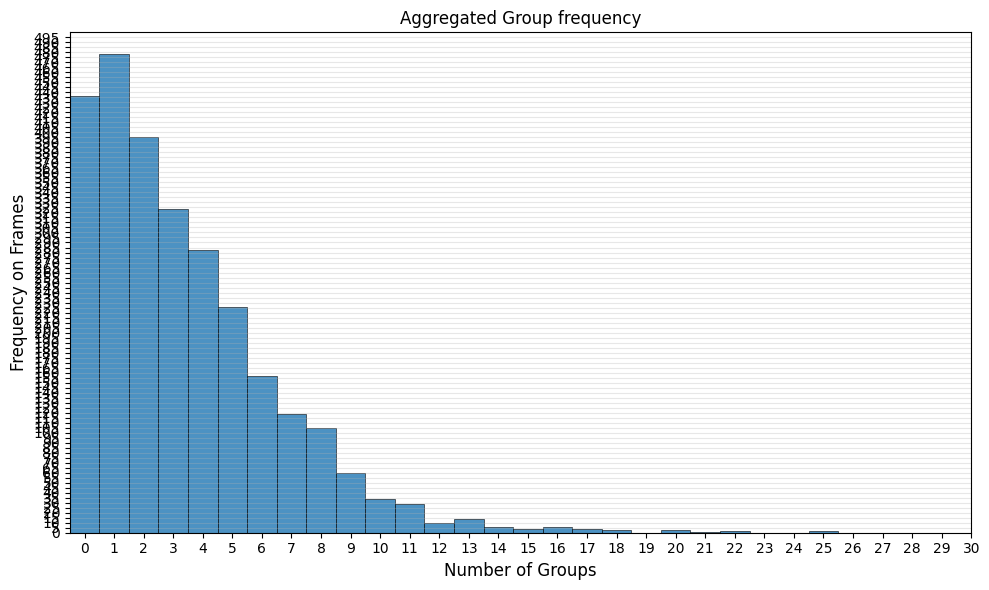

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data (approximate values from the image)
categories = np.arange(0,len(frequencies))

# COCO (3.5)
ours = frequencies
print(np.arange(30))
print(ours[:30])
# Create the plot
plt.figure(figsize=(10, 6))

# Plot bar chart
plt.bar(categories, ours, width=1.0, alpha=0.8, edgecolor='black', linewidth=0.5)

# Customize the plot
plt.xlabel('Number of Groups', fontsize=12)
plt.ylabel('Frequency on Frames', fontsize=12)
plt.title('Aggregated Group frequency', fontsize=12)
plt.xticks(categories)
plt.yticks(np.arange(0, 500, 5))
plt.ylim(0, 500)
plt.xlim(-0.5, 30)
plt.grid(True, alpha=0.3, axis='y')
#plt.legend(loc='upper right', fontsize=10)

# Format y-axis as percentages
ax = plt.gca()
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.tight_layout()
plt.savefig('../results/fig_annotations/Aggregated_Group_Frequency.pdf', format='pdf', bbox_inches='tight')
plt.show()

[  93  346  695 1564 6454]
[4 3 5 ... 4 4 5]


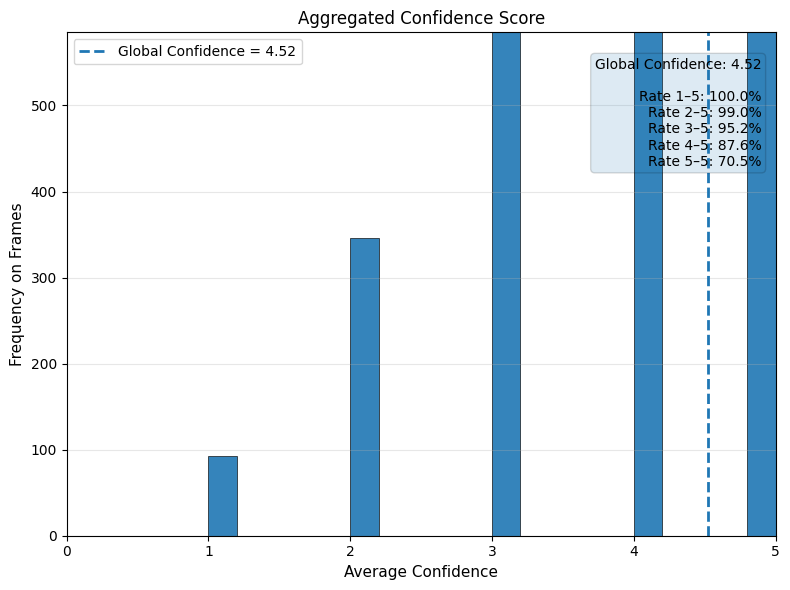

In [5]:
import matplotlib.pyplot as plt
import numpy as np

data = np.array(avg_score)
total = len(data)

# ---- Global confidence score (mean) ----
global_confidence = np.mean(data)
unique, counts = np.unique(data, return_counts=True)
print(counts)

# ---- Cumulative rates ----
rates = {
    "1–5": np.sum((data >= 1) & (data <= 5)) / total,
    "2–5": np.sum((data >= 2) & (data <= 5)) / total,
    "3–5": np.sum((data >= 3) & (data <= 5)) / total,
    "4–5": np.sum((data >= 4) & (data <= 5)) / total,
    "5–5": np.sum(data == 5) / total,
}

# ---- Plot ----
plt.figure(figsize=(8, 6))

plt.hist(
    data,
    bins=20,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9
)

print(data)

# Global confidence vertical line
plt.axvline(
    global_confidence,
    linestyle='--',
    linewidth=2,
    label=f'Global Confidence = {global_confidence:.2f}'
)

plt.xlabel('Average Confidence', fontsize=11)
plt.ylabel('Frequency on Frames', fontsize=11)
plt.title('Aggregated Confidence Score', fontsize=12)

plt.xlim(0, 5)
plt.ylim(0, 585)
plt.grid(True, alpha=0.3, axis='y')

# ---- Annotation text ----
text = (
    f"Global Confidence: {global_confidence:.2f}\n\n" +
    "\n".join([f"Rate {k}: {v*100:.1f}%" for k, v in rates.items()])
)

plt.text(
    0.98, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.legend()
plt.tight_layout()
plt.savefig('../results/fig_annotations/Aggregated_Confidence_Score.pdf', format='pdf', bbox_inches='tight')
plt.show()


## CONFIDENCE - CROWD, AREA and REGION

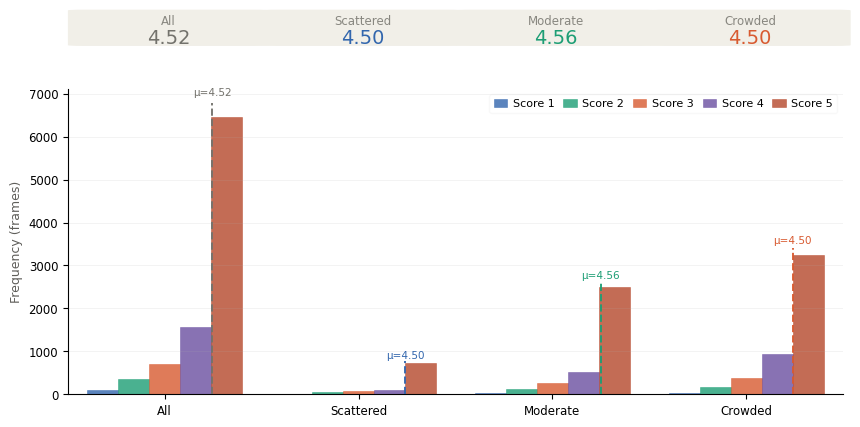

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Your data ────────────────────────────────────────────────────────────────
avg_score      = np.array(avg_score)
crowd_conf_low = np.array(crowd_confidence[0])
crowd_conf_med = np.array(crowd_confidence[1])
crowd_conf_hgh = np.array(crowd_confidence[2])

# ── Config ───────────────────────────────────────────────────────────────────
SCORE_BINS = [1, 2, 3, 4, 5]

SCORE_COLORS = {
    1: ("#3266ad", 0.80),
    2: ("#1D9E75", 0.80),
    3: ("#D85A30", 0.80),
    4: ("#6B4FA0", 0.80),
    5: ("#B5472A", 0.80),
}

groups = {
    "All":       avg_score,
    "Scattered": crowd_conf_low,
    "Moderate":  crowd_conf_med,
    "Crowded":   crowd_conf_hgh,
}

GROUP_COLORS = {
    "All":       "#73726c",
    "Scattered": "#3266ad",
    "Moderate":  "#1D9E75",
    "Crowded":   "#D85A30",
}

# ── Summary stats ─────────────────────────────────────────────────────────────
means = {name: np.mean(arr) for name, arr in groups.items()}

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[0.12, 1],
    hspace=0.25,
    figure=fig
)

# ── Metric cards (top row) ───────────────────────────────────────────────────
ax_cards = fig.add_subplot(gs[0])
ax_cards.axis("off")

card_x    = [0.02, 0.27, 0.52, 0.77]
card_w    = 0.22
card_h    = 0.95
card_bg   = "#f1efe8"
label_col = "#888780"

for x, (name, mean_val) in zip(card_x, means.items()):
    color = GROUP_COLORS[name]
    ax_cards.add_patch(FancyBboxPatch(
        (x, 0.02), card_w, card_h,
        boxstyle="round,pad=0.02",
        linewidth=0,
        facecolor=card_bg,
        transform=ax_cards.transAxes,
        clip_on=False
    ))
    ax_cards.text(
        x + card_w / 2, 0.68, name,
        transform=ax_cards.transAxes,
        ha="center", va="center",
        fontsize=8.5, color=label_col
    )
    ax_cards.text(
        x + card_w / 2, 0.22, f"{mean_val:.2f}",
        transform=ax_cards.transAxes,
        ha="center", va="center",
        fontsize=14, fontweight="medium", color=color
    )

# ── Vertical bar chart — groups on X, scores as hue ──────────────────────────
ax_hist = fig.add_subplot(gs[1])

group_names = list(groups.keys())
n_groups    = len(group_names)
n_scores    = len(SCORE_BINS)
bar_w       = 0.8 / n_scores
x_base      = np.arange(n_groups, dtype=float)

# Store bar offsets per score so we can interpolate the mean position
score_offsets = {}
for j, score in enumerate(SCORE_BINS):
    offset = (j - (n_scores - 1) / 2) * bar_w
    score_offsets[score] = offset
    color, alpha = SCORE_COLORS[score]
    counts = np.array([np.sum(arr == score) for arr in groups.values()], dtype=float)
    ax_hist.bar(
        x_base + offset, counts,
        width=bar_w, alpha=alpha,
        color=color, edgecolor=color,
        linewidth=0.4,
        label=f"Score {score}"
    )

# ── Mean line at the interpolated x position within each group cluster ────────
# The bar centers for scores 1–5 within group i are at:
#   x_base[i] + score_offsets[score]
# The mean score maps linearly onto those positions.
# We interpolate: x_mean = x_base[i] + interp(mean, SCORE_BINS, offsets)
score_centers = np.array([score_offsets[s] for s in SCORE_BINS])

for i, (name, arr) in enumerate(groups.items()):
    color = GROUP_COLORS[name]
    mean  = means[name]

    # interpolate mean score → x offset within the cluster
    x_mean = x_base[i] + np.interp(mean, SCORE_BINS, score_centers)

    group_counts = np.array([np.sum(arr == s) for s in SCORE_BINS], dtype=float)
    line_top = group_counts.max() * 1.05

    ax_hist.vlines(
        x_mean, 0, line_top,
        color=color, linestyle="--",
        linewidth=1.4, alpha=0.95,
        zorder=5
    )
    ax_hist.text(
        x_mean, line_top * 1.02,
        f"μ={mean:.2f}",
        ha="center", va="bottom",
        fontsize=7.5, color=color, fontweight="medium"
    )

ax_hist.set_ylabel("Frequency (frames)", fontsize=9, color="#5F5E5A")
ax_hist.set_xticks(x_base)
ax_hist.set_xticklabels(group_names, fontsize=9)
ax_hist.set_xlim(-0.5, n_groups - 0.5)
ax_hist.grid(axis="y", alpha=0.2, linewidth=0.5)
ax_hist.spines[["top", "right"]].set_visible(False)
ax_hist.tick_params(labelsize=8.5)
ax_hist.legend(
    fontsize=8, framealpha=0.12, edgecolor="#cccccc",
    loc="upper right", ncol=5,
    handlelength=1.2, handletextpad=0.5, columnspacing=0.8
)

plt.savefig(
    "../results/fig_annotations/Confidence_Crowded.pdf",
    format="pdf", bbox_inches="tight", dpi=150
)
plt.show()

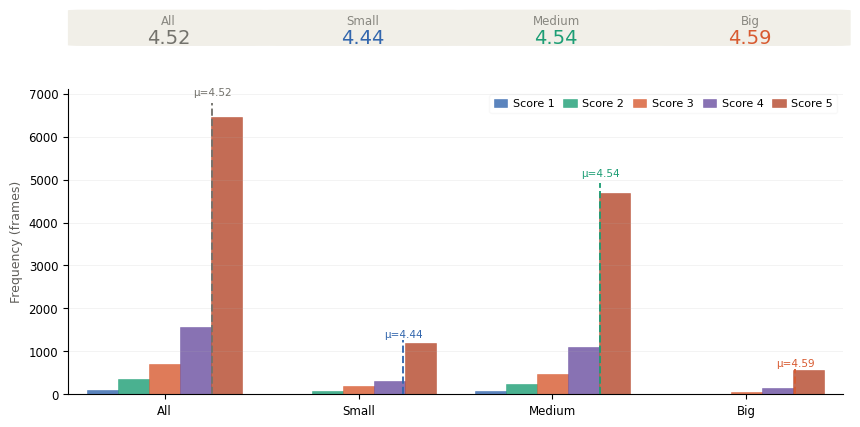

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Your data ────────────────────────────────────────────────────────────────
avg_score      = np.array(avg_score)
crowd_conf_low = np.array(area_confidence[0])
crowd_conf_med = np.array(area_confidence[1])
crowd_conf_hgh = np.array(area_confidence[2])

# ── Config ───────────────────────────────────────────────────────────────────
SCORE_BINS = [1, 2, 3, 4, 5]

SCORE_COLORS = {
    1: ("#3266ad", 0.80),
    2: ("#1D9E75", 0.80),
    3: ("#D85A30", 0.80),
    4: ("#6B4FA0", 0.80),
    5: ("#B5472A", 0.80),
}

groups = {
    "All":       avg_score,
    "Small": crowd_conf_low,
    "Medium":  crowd_conf_med,
    "Big":   crowd_conf_hgh,
}

GROUP_COLORS = {
    "All":       "#73726c",
    "Small": "#3266ad",
    "Medium":  "#1D9E75",
    "Big":   "#D85A30",
}

# ── Summary stats ─────────────────────────────────────────────────────────────
means = {name: np.mean(arr) for name, arr in groups.items()}

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[0.12, 1],
    hspace=0.25,
    figure=fig
)

# ── Metric cards (top row) ───────────────────────────────────────────────────
ax_cards = fig.add_subplot(gs[0])
ax_cards.axis("off")

card_x    = [0.02, 0.27, 0.52, 0.77]
card_w    = 0.22
card_h    = 0.95
card_bg   = "#f1efe8"
label_col = "#888780"

for x, (name, mean_val) in zip(card_x, means.items()):
    color = GROUP_COLORS[name]
    ax_cards.add_patch(FancyBboxPatch(
        (x, 0.02), card_w, card_h,
        boxstyle="round,pad=0.02",
        linewidth=0,
        facecolor=card_bg,
        transform=ax_cards.transAxes,
        clip_on=False
    ))
    ax_cards.text(
        x + card_w / 2, 0.68, name,
        transform=ax_cards.transAxes,
        ha="center", va="center",
        fontsize=8.5, color=label_col
    )
    ax_cards.text(
        x + card_w / 2, 0.22, f"{mean_val:.2f}",
        transform=ax_cards.transAxes,
        ha="center", va="center",
        fontsize=14, fontweight="medium", color=color
    )

# ── Vertical bar chart — groups on X, scores as hue ──────────────────────────
ax_hist = fig.add_subplot(gs[1])

group_names = list(groups.keys())
n_groups    = len(group_names)
n_scores    = len(SCORE_BINS)
bar_w       = 0.8 / n_scores
x_base      = np.arange(n_groups, dtype=float)

# Store bar offsets per score so we can interpolate the mean position
score_offsets = {}
for j, score in enumerate(SCORE_BINS):
    offset = (j - (n_scores - 1) / 2) * bar_w
    score_offsets[score] = offset
    color, alpha = SCORE_COLORS[score]
    counts = np.array([np.sum(arr == score) for arr in groups.values()], dtype=float)
    ax_hist.bar(
        x_base + offset, counts,
        width=bar_w, alpha=alpha,
        color=color, edgecolor=color,
        linewidth=0.4,
        label=f"Score {score}"
    )

# ── Mean line at the interpolated x position within each group cluster ────────
# The bar centers for scores 1–5 within group i are at:
#   x_base[i] + score_offsets[score]
# The mean score maps linearly onto those positions.
# We interpolate: x_mean = x_base[i] + interp(mean, SCORE_BINS, offsets)
score_centers = np.array([score_offsets[s] for s in SCORE_BINS])

for i, (name, arr) in enumerate(groups.items()):
    color = GROUP_COLORS[name]
    mean  = means[name]

    # interpolate mean score → x offset within the cluster
    x_mean = x_base[i] + np.interp(mean, SCORE_BINS, score_centers)

    group_counts = np.array([np.sum(arr == s) for s in SCORE_BINS], dtype=float)
    line_top = group_counts.max() * 1.05

    ax_hist.vlines(
        x_mean, 0, line_top,
        color=color, linestyle="--",
        linewidth=1.4, alpha=0.95,
        zorder=5
    )
    ax_hist.text(
        x_mean, line_top * 1.02,
        f"μ={mean:.2f}",
        ha="center", va="bottom",
        fontsize=7.5, color=color, fontweight="medium"
    )

ax_hist.set_ylabel("Frequency (frames)", fontsize=9, color="#5F5E5A")
ax_hist.set_xticks(x_base)
ax_hist.set_xticklabels(group_names, fontsize=9)
ax_hist.set_xlim(-0.5, n_groups - 0.5)
ax_hist.grid(axis="y", alpha=0.2, linewidth=0.5)
ax_hist.spines[["top", "right"]].set_visible(False)
ax_hist.tick_params(labelsize=8.5)
ax_hist.legend(
    fontsize=8, framealpha=0.12, edgecolor="#cccccc",
    loc="upper right", ncol=5,
    handlelength=1.2, handletextpad=0.5, columnspacing=0.8
)

plt.savefig(
    "../results/fig_annotations/Confidence_Area.pdf",
    format="pdf", bbox_inches="tight", dpi=150
)
plt.show()

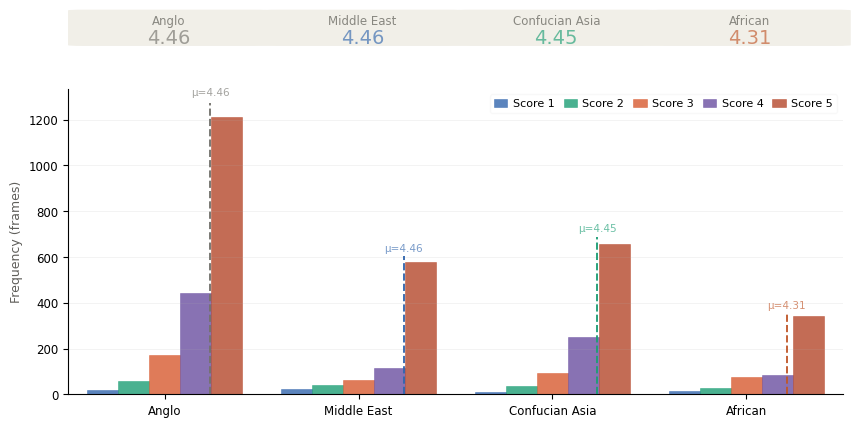

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np


AN  = np.array(region_confidence['Anglo'])
ME  = np.array(region_confidence['Middle East'])
CA  = np.array(region_confidence['Confucian Asia'])
SEA = np.array(region_confidence['South-East Asia'])
LE  = np.array(region_confidence['Latin Europe'])
EE  = np.array(region_confidence['Eastern Europe'])
LA  = np.array(region_confidence['Latin America'])
OT  = np.array(region_confidence['Other'])
AF  = np.array(region_confidence['African'])
GE  = np.array(region_confidence['Germanic Europe'])
NE  = np.array(region_confidence['Nordic Europe'])
EAE = np.array(region_confidence['Easter Europe'])



# ── Config ───────────────────────────────────────────────────────────────────
SCORE_BINS = [1, 2, 3, 4, 5]

SCORE_COLORS = {
    1: ("#3266ad", 0.80),
    2: ("#1D9E75", 0.80),
    3: ("#D85A30", 0.80),
    4: ("#6B4FA0", 0.80),
    5: ("#B5472A", 0.80),
}

groups = {
    "Anglo":           AN,
    "Middle East":     ME,
    "Confucian Asia":  CA,
    #"South-East Asia": SEA,
    #"Latin Europe":    LE,
    #"Eastern Europe":  EE,
    #"Latin America":   LA,
    #"Other":           OT,
    "African":         AF,
    #"Germanic Europe": GE,
    #"Nordic Europe":   NE,
    #"Easter Europe":   EAE,
}

GROUP_COLORS = {
    "Anglo":           ("#73726c", 0.65),
    "Middle East":     ("#3266ad", 0.65),
    "Confucian Asia":  ("#1D9E75", 0.65),
    #"South-East Asia": ("#D85A30", 0.65),
    #"Latin Europe":    ("#6B4FA0", 0.65),
    #"Eastern Europe":  ("#B5472A", 0.65),
    #"Latin America":   ("#2A7F7F", 0.65),
    #"Other":           ("#A0522D", 0.65),
    "African":         ("#C0572A", 0.65),
    #"Germanic Europe": ("#4A7C3F", 0.65),
    #"Nordic Europe":   ("#7B3F8C", 0.65),
    #"Easter Europe":   ("#3B6EA5", 0.65),
}

# ── Summary stats ─────────────────────────────────────────────────────────────
means = {name: np.mean(arr) for name, arr in groups.items()}

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[0.12, 1],
    hspace=0.25,
    figure=fig
)

# ── Metric cards (top row) ───────────────────────────────────────────────────
ax_cards = fig.add_subplot(gs[0])
ax_cards.axis("off")

card_x    = [0.02, 0.27, 0.52, 0.77]
card_w    = 0.22
card_h    = 0.95
card_bg   = "#f1efe8"
label_col = "#888780"

for x, (name, mean_val) in zip(card_x, means.items()):
    color = GROUP_COLORS[name]
    ax_cards.add_patch(FancyBboxPatch(
        (x, 0.02), card_w, card_h,
        boxstyle="round,pad=0.02",
        linewidth=0,
        facecolor=card_bg,
        transform=ax_cards.transAxes,
        clip_on=False
    ))
    ax_cards.text(
        x + card_w / 2, 0.68, name,
        transform=ax_cards.transAxes,
        ha="center", va="center",
        fontsize=8.5, color=label_col
    )
    ax_cards.text(
        x + card_w / 2, 0.22, f"{mean_val:.2f}",
        transform=ax_cards.transAxes,
        ha="center", va="center",
        fontsize=14, fontweight="medium", color=color
    )

# ── Vertical bar chart — groups on X, scores as hue ──────────────────────────
ax_hist = fig.add_subplot(gs[1])

group_names = list(groups.keys())
n_groups    = len(group_names)
n_scores    = len(SCORE_BINS)
bar_w       = 0.8 / n_scores
x_base      = np.arange(n_groups, dtype=float)

# Store bar offsets per score so we can interpolate the mean position
score_offsets = {}
for j, score in enumerate(SCORE_BINS):
    offset = (j - (n_scores - 1) / 2) * bar_w
    score_offsets[score] = offset
    color, alpha = SCORE_COLORS[score]
    counts = np.array([np.sum(arr == score) for arr in groups.values()], dtype=float)
    ax_hist.bar(
        x_base + offset, counts,
        width=bar_w, alpha=alpha,
        color=color, edgecolor=color,
        linewidth=0.4,
        label=f"Score {score}"
    )

# ── Mean line at the interpolated x position within each group cluster ────────
# The bar centers for scores 1–5 within group i are at:
#   x_base[i] + score_offsets[score]
# The mean score maps linearly onto those positions.
# We interpolate: x_mean = x_base[i] + interp(mean, SCORE_BINS, offsets)
score_centers = np.array([score_offsets[s] for s in SCORE_BINS])

for i, (name, arr) in enumerate(groups.items()):
    color = GROUP_COLORS[name]
    mean  = means[name]

    # interpolate mean score → x offset within the cluster
    x_mean = x_base[i] + np.interp(mean, SCORE_BINS, score_centers)

    group_counts = np.array([np.sum(arr == s) for s in SCORE_BINS], dtype=float)
    line_top = group_counts.max() * 1.05

    ax_hist.vlines(
        x_mean, 0, line_top,
        color=color, linestyle="--",
        linewidth=1.4, alpha=0.95,
        zorder=5
    )
    ax_hist.text(
        x_mean, line_top * 1.02,
        f"μ={mean:.2f}",
        ha="center", va="bottom",
        fontsize=7.5, color=color, fontweight="medium"
    )

ax_hist.set_ylabel("Frequency (frames)", fontsize=9, color="#5F5E5A")
ax_hist.set_xticks(x_base)
ax_hist.set_xticklabels(group_names, fontsize=9)
ax_hist.set_xlim(-0.5, n_groups - 0.5)
ax_hist.grid(axis="y", alpha=0.2, linewidth=0.5)
ax_hist.spines[["top", "right"]].set_visible(False)
ax_hist.tick_params(labelsize=8.5)
ax_hist.legend(
    fontsize=8, framealpha=0.12, edgecolor="#cccccc",
    loc="upper right", ncol=5,
    handlelength=1.2, handletextpad=0.5, columnspacing=0.8
)

plt.savefig(
    "../results/fig_annotations/Confidence_Crowded.pdf",
    format="pdf", bbox_inches="tight", dpi=150
)
plt.show()

# REBUTTAL FIGURE

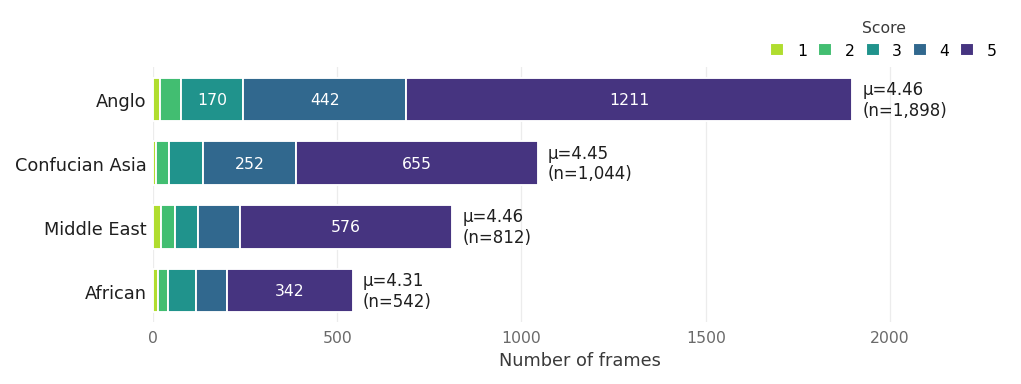

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

AN_values, AN_counts = np.unique(AN, return_counts=True)
ME_values, ME_counts = np.unique(ME, return_counts=True)
CA_values, CA_counts = np.unique(CA, return_counts=True)
AF_values, AF_counts = np.unique(AF, return_counts=True)

data = {
    "Region": ["Anglo", "Middle East", "Confucian Asia", "African"],
    "Score 1": [AN_counts[0], ME_counts[0], CA_counts[0], AF_counts[0]],
    "Score 2": [AN_counts[1], ME_counts[1], CA_counts[1], AF_counts[1]],
    "Score 3": [AN_counts[2], ME_counts[2], CA_counts[2], AF_counts[2]],
    "Score 4": [AN_counts[3], ME_counts[3], CA_counts[3], AF_counts[3]],
    "Score 5": [AN_counts[4], ME_counts[4], CA_counts[4], AF_counts[4]],
}
counts = pd.DataFrame(data).set_index("Region")
score_values = pd.Series([1, 2, 3, 4, 5], index=counts.columns)
means = counts.mul(score_values, axis=1).sum(axis=1) / counts.sum(axis=1)

#order = means.sort_values(ascending=True).index
#print(order)
order = ['Anglo', 'Confucian Asia', 'Middle East', 'African'][::-1]
counts = counts.loc[order]
means = means.loc[order]
totals = counts.sum(axis=1)
proportions = counts.div(totals, axis=0) * 100

colors = plt.cm.viridis(np.linspace(0.15, 0.88, 5))
colors = colors[::-1]

fig, ax = plt.subplots(figsize=(7.2, 2.5), dpi=150)
fig.patch.set_facecolor("white")

xmax = totals.max() * 1.22
MIN_LABEL_FRAC = 0.05

left = np.zeros(len(counts))
for i, col in enumerate(counts.columns):
    vals = counts[col].values
    ax.barh(counts.index, vals, left=left,
            color=colors[i], edgecolor="white", linewidth=0.9,
            height=0.68, label=col.replace("Score ", ""))
    for j, v in enumerate(vals):
        if v / xmax >= MIN_LABEL_FRAC:
            ax.text(left[j] + v / 2, j, f"{int(v)}",
                    ha="center", va="center",
                    color="white" if i >= 2 else "#f0f0f0",
                    fontsize=7.5, fontweight="medium")
    left += vals

for i, region in enumerate(counts.index):
    ax.text(totals.iloc[i] + xmax * 0.012, i,
            f"μ={means.iloc[i]:.2f}\n(n={int(totals.iloc[i]):,})",
            va="center", ha="left",
            fontsize=8, color="#1f1f1f")

ax.set_xlim(0, xmax)
ax.set_xlabel("Number of frames", fontsize=8.5, color="#3a3a3a", labelpad=3)
ax.tick_params(axis="y", length=0, labelsize=8.5, colors="#1f1f1f", pad=3)
ax.tick_params(axis="x", length=0, labelsize=7.5, colors="#6a6a6a")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#ececec", linewidth=0.6)
ax.yaxis.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

handles = [mpatches.Patch(facecolor=colors[i], edgecolor="white", label=f"{i+1}")
           for i in range(5)]
leg = ax.legend(handles=handles, title="Score",
                loc="lower right", bbox_to_anchor=(1.0, 1.0),
                ncol=5, frameon=False, handlelength=0.9, handleheight=0.9,
                columnspacing=0.7, fontsize=7.5, title_fontsize=7.5,
                borderaxespad=0.2)
leg.get_title().set_color("#3a3a3a")

ax.set_ylim(-0.5, len(counts) - 0.5)
plt.subplots_adjust(top=0.88, bottom=0.20, left=0.18, right=0.97)
plt.savefig("score_dist_rebuttal.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()

# REGION CROWDNESS

In [10]:
print(region_density)

defaultdict(<function <lambda> at 0x74732ff24b80>, {'African': [57, 102, 66], 'Anglo': [84, 156, 243], 'Middle East': [93, 117, 45], 'Confucian Asia': [135, 90, 117], 'South-East Asia': [90, 87, 63], 'Nordic Europe': [168, 45, 3], 'Latin Europe': [69, 66, 135], 'Eastern Europe': [90, 54, 63], 'Latin America': [99, 90, 36], 'Other': [6, 9, 15], 'Germanic Europe': [9, 84, 114]})


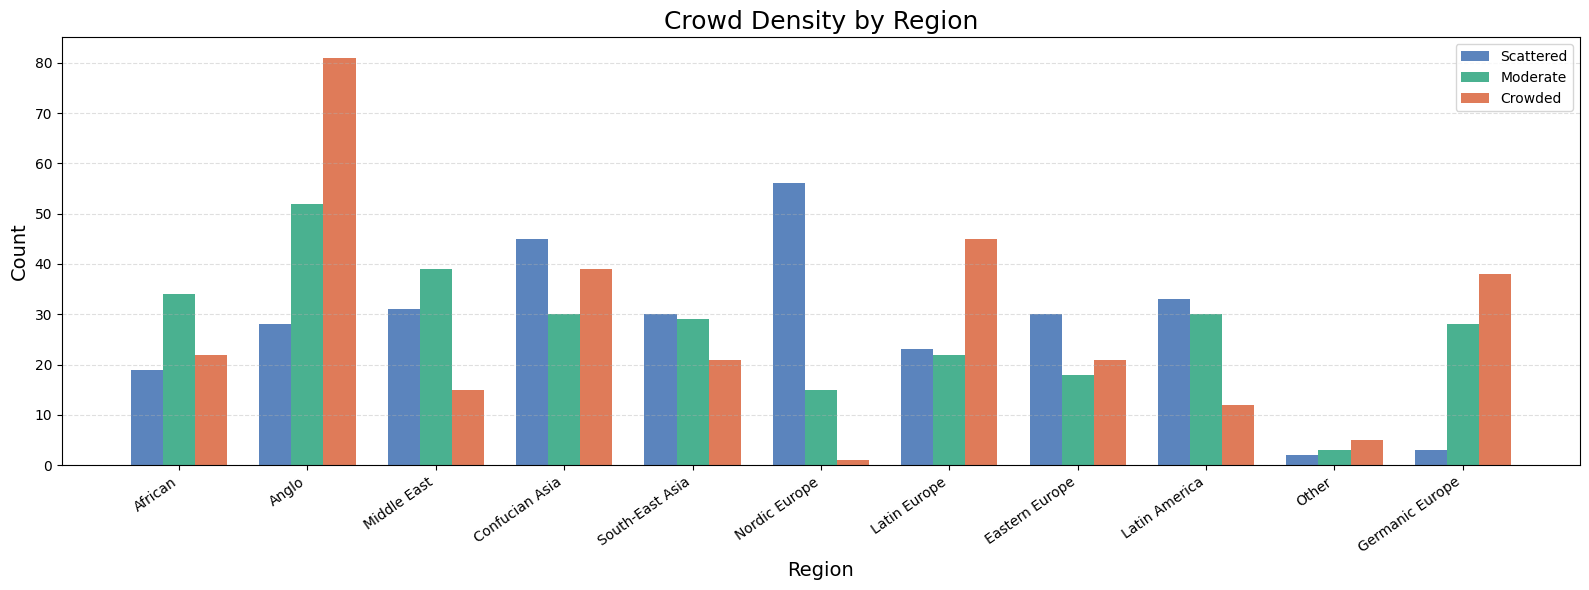

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

region_density = {
    region: [x / 3 for x in values]
    for region, values in region_density.items()
}
# # Input data
# region_density = defaultdict(
#     lambda: [0, 0, 0],
#     {
#         'African': [24, 21, 30],
#         'Anglo': [87, 156, 243],
#         'Middle East': [69, 84, 15],
#         'Confucian Asia': [135, 96, 123],
#         'South-East Asia': [48, 51, 21],
#         'Nordic Europe': [54, 24, 0],
#         'Latin Europe': [30, 33, 48],
#         'Eastern Europe': [42, 18, 15],
#         'Latin America': [48, 27, 12],
#         'Other': [0, 6, 9],
#         'Germanic Europe': [3, 24, 24]
#     }
# )

# Custom colors and alpha
colors = {
    1: ("#3266ad", 0.80),  # Blue
    2: ("#1D9E75", 0.80),  # Green
    3: ("#D85A30", 0.80),  # Orange
}

# Regions
regions = list(region_density.keys())

# Density groups
low_density = [region_density[r][0] for r in regions]
medium_density = [region_density[r][1] for r in regions]
high_density = [region_density[r][2] for r in regions]

# X positions
x = np.arange(len(regions))
width = 0.25

# Figure
fig, ax = plt.subplots(figsize=(16, 6))

# Bars
ax.bar(
    x - width,
    low_density,
    width,
    label='Scattered',
    color=colors[1][0],
    alpha=colors[1][1]
)

ax.bar(
    x,
    medium_density,
    width,
    label='Moderate',
    color=colors[2][0],
    alpha=colors[2][1]
)

ax.bar(
    x + width,
    high_density,
    width,
    label='Crowded',
    color=colors[3][0],
    alpha=colors[3][1]
)

# Labels
ax.set_title('Crowd Density by Region', fontsize=18)
ax.set_xlabel('Region', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(regions, rotation=35, ha='right')

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
ax.legend()

# Layout
plt.tight_layout()

# Save image
plt.savefig(
    "crowd_density_by_region.png",
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()

# LAST FIGURE

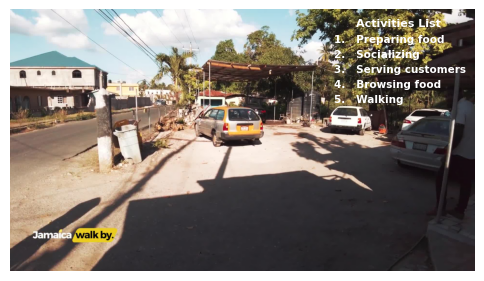

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from matplotlib.lines import Line2D

# Load image
image = cv2.imread('../videos/clip_0001/00001.jpeg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(image)

# Left column: numbers
confidence_values = [1, 2, 3, 4, 5]
left_labels = [f"{i+1}." for i in range(len(confidence_values))]

# Right column: your activity names
right_labels = ["Preparing food", "Socializing", "Serving customers", "Browsing food", "Walking", "Shopping", "Selling food", "Eating"]

# Combine into rows:  "1.  Walking", etc.
combined_labels = [f"{left:<3}  {right}" for left, right in zip(left_labels, right_labels)]

# Invisible handles
empty_handles = [Line2D([], [], linestyle="none") for _ in combined_labels]

legend = ax.legend(
    empty_handles,
    combined_labels,
    title="Activities List",
    loc="upper right",
    frameon=False,
    handlelength=0,
    handletextpad=0.2,
    prop={'size': 7.5, 'weight': 'bold'},
    title_fontsize=8
)

# Style text
for text in legend.get_texts():
    text.set_color("white")

legend.get_title().set_color("white")
legend.get_title().set_fontweight("bold")

ax.axis("off")
plt.savefig("../results/fig_annotations/sample_activities_list.pdf", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()